In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron, eye
from scipy.sparse.linalg import eigs
import scipy.sparse as sp

## definición de parámetros y creación de la malla

parámetros de la guia de onda

In [2]:
a = 2 # x
b = 1 # y

discretizacioń de la malla

In [3]:
Nx = 40
Ny = 20

espaciado entre puntos

In [4]:
dx = a / (Nx - 1)
dy = b / (Ny - 1)

puntos interiores (exluimos fronteras donde Ez = 0)

In [5]:
nx = Nx - 2      # Número de puntos interiores en x
ny = Ny - 2     # Número de puntos interiores en y
N_interior = nx * ny  # Total de puntos interiores

In [6]:
print(f"Dominio: a={a}m, b={b}m")
print(f"Malla: {Nx}×{Ny} puntos totales ({nx}×{ny} puntos interiores = {N_interior} incógnitas)")
print(f"dx = {dx:.4f}m, dy = {dy:.4f}m")

Dominio: a=2m, b=1m
Malla: 40×20 puntos totales (38×18 puntos interiores = 684 incógnitas)
dx = 0.0513m, dy = 0.0526m


creación de la malla para graficación

In [7]:
x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)
X, Y = np.meshgrid(x, y)   

creación de las matrices de de segunda derivada en 1D

 MATRIZ DE SEGUNDA DERIVADA EN 1D (DIRECCIÓN X)

Para puntos interiores, usamos la fórmula de diferencias finitas centradas:

 $$
\frac{d²f}{dx²} ≈ \frac{(f_{i-1} - 2f_i + f_{i+1})}{ dx²}
 $$

In [8]:
# Diagonal principal: -2/dx²
# Diagonales superior e inferior: 1/dx²
diagonales_x = [np.ones(nx-1), -2*np.ones(nx), np.ones(nx-1)]
offsets_x = [-1, 0, 1]  # Posiciones de las diagonales

D2x = (1/dx**2) * diags(diagonales_x, offsets_x, format='csr')
print(f"\nMatriz D2x dimensiones: {D2x.shape}")




Matriz D2x dimensiones: (38, 38)


MATRIZ DE SEGUNDA DERIVADA EN 1D (DIRECCIÓN Y)

In [9]:

diagonales_y = [np.ones(ny-1), -2*np.ones(ny), np.ones(ny-1)]
offsets_y = [-1, 0, 1]

D2y = (1/dy**2) * diags(diagonales_y, offsets_y, format='csr')
print(f"Matriz D2y dimensiones: {D2y.shape}")

Matriz D2y dimensiones: (18, 18)


Construcción del laplaciano 2D usando producto de Kronecker

LAPLACIANO 2D CON PRODUCTO DE KRONECKER

El laplaciano 2D se construye como:
$$
L2D = I_y ⊗ D2x + D2y ⊗ I_x
$$
Donde $⊗$ es el producto de Kronecker

$I_x$ es matriz identidad de tamaño nx
$I_y$ es matriz identidad de tamaño ny

In [10]:
Ix = eye(nx, format='csr')  # Identidad para dimensión x
Iy = eye(ny, format='csr')  # Identidad para dimensión y

# Primer término: Derivadas en x para todas las filas
termino_x = kron(Iy, D2x, format='csr')

# Segundo término: Derivadas en y para todas las columnas
termino_y = kron(D2y, Ix, format='csr')

# Laplaciano completo
L2D = termino_x + termino_y
print(f"\nMatriz Laplaciano 2D dimensiones: {L2D.shape}")
print(f"Número de elementos no cero: {L2D.nnz}")
print(f"Densidad: {100 * L2D.nnz / (N_interior**2):.4f}%")


Matriz Laplaciano 2D dimensiones: (684, 684)
Número de elementos no cero: 3308
Densidad: 0.7071%


Visualización de la estructura de la matriz

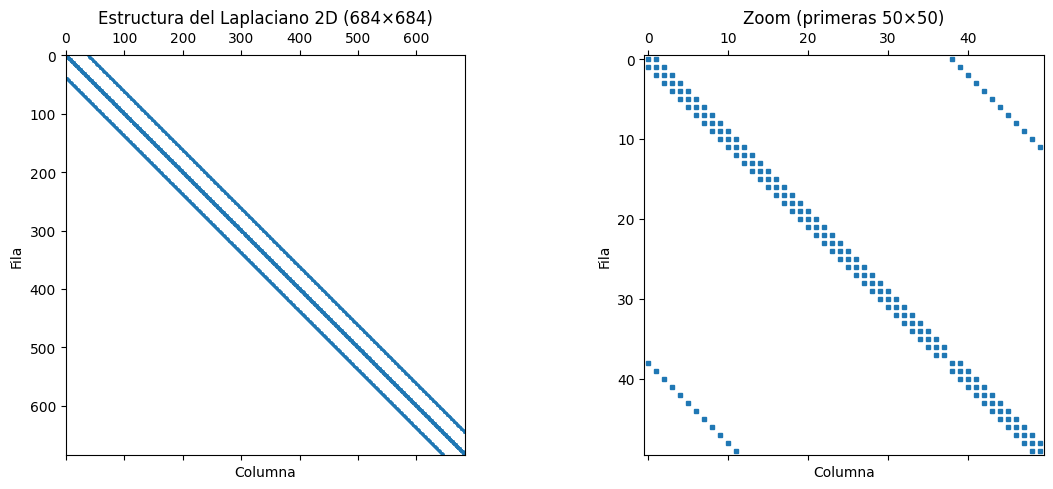

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.spy(L2D, markersize=1)
plt.title(f'Estructura del Laplaciano 2D ({L2D.shape[0]}×{L2D.shape[1]})')
plt.xlabel('Columna')
plt.ylabel('Fila')

plt.subplot(1, 2, 2)
# Mostrar un zoom de la esquina superior izquierda
plt.spy(L2D[:50, :50], markersize=3)
plt.title('Zoom (primeras 50×50)')
plt.xlabel('Columna')
plt.ylabel('Fila')

plt.tight_layout()
plt.show()

Resolución del problema de autovalores

Queremos resolver: $L2D * E = -k_c² * E$

O equivalentemente: $-L2D * E = k_c² * E$

In [12]:
# Usamos eigs para encontrar los primeros autovalores

num_modos = 6  # Número de modos a calcular

# Resolvemos -L2D para obtener k_c² positivos
autovalores, autovectores = eigs(-L2D, k=num_modos, which='SM')

# Ordenamos de menor a mayor
idx = autovalores.real.argsort()
autovalores = autovalores.real[idx]
autovectores = autovectores[:, idx]

print("\n--- AUTOVALORES ENCONTRADOS (k_c²) ---")
for i, val in enumerate(autovalores):
    print(f"Modo {i+1}: k_c² = {val:.6f}")


--- AUTOVALORES ENCONTRADOS (k_c²) ---
Modo 1: k_c² = 12.313206
Modo 2: k_c² = 19.695414
Modo 3: k_c² = 31.945887
Modo 4: k_c² = 41.586019
Modo 5: k_c² = 48.968227
Modo 6: k_c² = 48.985175


Comparación con solución analítica

In [13]:
# Para modos TM, la solución analítica es:
# k_c²_mn = (mπ/a)² + (nπ/b)²

print("\n--- COMPARACIÓN CON VALORES ANALÍTICOS ---")
print("Modo\tNumérico\tAnalítico\tError Relativo")

# Generamos los primeros modos analíticos ordenados
modos_analiticos = []
for m in range(1, 5):
    for n in range(1, 5):
        kc2_ana = (m*np.pi/a)**2 + (n*np.pi/b)**2
        modos_analiticos.append((kc2_ana, m, n))

# Ordenamos por valor de kc²
modos_analiticos.sort()

# Comparamos
for i in range(num_modos):
    kc2_num = autovalores[i]
    kc2_ana, m, n = modos_analiticos[i]
    error = 100 * abs(kc2_num - kc2_ana) / kc2_ana
    print(f"TM{m}{n}\t{kc2_num:.6f}\t{kc2_ana:.6f}\t{error:.4f}%")


--- COMPARACIÓN CON VALORES ANALÍTICOS ---
Modo	Numérico	Analítico	Error Relativo
TM11	12.313206	12.337006	0.1929%
TM21	19.695414	19.739209	0.2219%
TM31	31.945887	32.076214	0.4063%
TM12	41.586019	41.945819	0.8578%
TM22	48.968227	49.348022	0.7696%
TM41	48.985175	49.348022	0.7353%


Reconstrucción y visualización de los modos

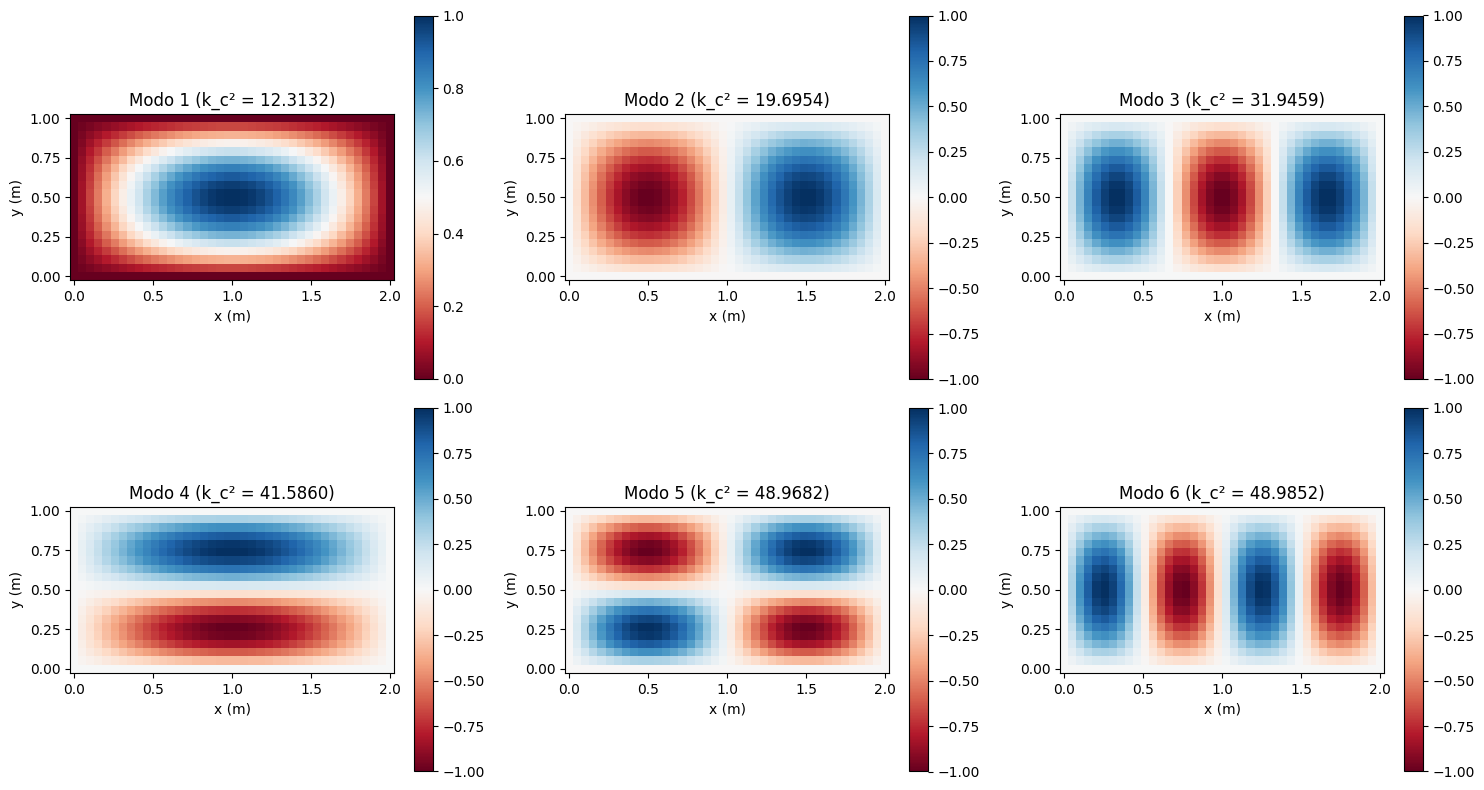

In [14]:
# Creamos una figura con subgráficas para varios modos
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for modo in range(num_modos):
    # Extraemos el autovector para este modo
    vector_modo = autovectores[:, modo].real
    
    # Reconstruimos la matriz 2D (solo puntos interiores)
    Ez_interior = vector_modo.reshape((ny, nx))
    
    # Normalizamos para visualización
    Ez_interior = Ez_interior / np.max(np.abs(Ez_interior))
    
    # Creamos la matriz completa incluyendo bordes (con ceros)
    Ez_full = np.zeros((Ny, Nx))
    Ez_full[1:-1, 1:-1] = Ez_interior
    
    # Graficamos
    im = axes[modo].pcolormesh(X, Y, Ez_full, cmap='RdBu', shading='auto')
    axes[modo].set_title(f'Modo {modo+1} (k_c² = {autovalores[modo]:.4f})')
    axes[modo].set_xlabel('x (m)')
    axes[modo].set_ylabel('y (m)')
    axes[modo].set_aspect('equal')
    plt.colorbar(im, ax=axes[modo])

plt.tight_layout()
plt.show()